In [1]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, make_scorer, precision_score, f1_score, confusion_matrix
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.decomposition import PCA
from sklearn.svm import SVC, LinearSVC
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import LabelEncoder
import re
import nltk
from nltk.corpus import stopwords

In [27]:
df.head()

,text,labels,no_sentences,Flesch Reading Ease Score,Dale-Chall Readability Score,text_rank_summary,lsa_summary
0,Ad sales boost Time Warner profit\n\nQuarterly...,business,26,62.17,9.72,It hopes to increase subscribers by offering t...,Its profits were buoyed by one-off gains which...
1,Dollar gains on Greenspan speech\n\nThe dollar...,business,17,65.56,9.09,The dollar has hit its highest level against t...,"""I think the chairman's taking a much more san..."
2,Yukos unit buyer faces loan claim\n\nThe owner...,business,14,69.21,9.66,The owners of embattled Russian oil giant Yuko...,Yukos' owner Menatep Group says it will ask Ro...
3,High fuel prices hit BA's profits\n\nBritish A...,business,24,62.98,9.86,Looking ahead to its full year results to Marc...,"Rod Eddington, BA's chief executive, said the ..."
4,Pernod takeover talk lifts Domecq\n\nShares in...,business,17,70.63,10.23,Reports in the Wall Street Journal and the Fin...,Shares in UK drinks and food firm Allied Domec...


In [1]:
#Original data frame

df = pd.read_csv("G:/My Drive/Applied Data Science Mining - 502/Final Project/bbc_news_text_complexity_summarization.csv")

In [35]:
from scipy.sparse import hstack
from scipy.sparse import csr_matrix

X_base_cat = df[['text', 'text_rank_summary', 'lsa_summary']]
X_base_num = df[['no_sentences', 'Flesch Reading Ease Score', 'Dale-Chall Readability Score']]
categorical_cols = X_base_cat.columns

vectorizers = {}
tfidf_features = []

for col in categorical_cols:
    vectorizer = TfidfVectorizer(analyzer = 'char_wb', max_features=100, 
                                 max_df = 0.9, min_df = 5, ngram_range = (1, 3))  # Adjust `max_features` as needed
    tfidf = vectorizer.fit_transform(X_base_cat[col])
    vectorizers[col] = vectorizer  # Save vectorizer for later use if needed
    tfidf_features.append(tfidf)

# Combine all TF-IDF features
X_categorical_tfidf = hstack(tfidf_features)

# Convert numeric data to sparse format if using sparse TF-IDF
X_numeric_sparse = csr_matrix(X_base_num.values)

# Combine numeric and categorical features
X_combined = hstack([X_numeric_sparse, X_categorical_tfidf])

In [36]:
#X_base_cat = df[['text', 'text_rank_summary', 'lsa_summary']]
#X_base_num = df[['no_sentences', 'Flesch Reading Ease Score', 'Dale-Chall Readability Score']]
y_base = df['labels']

label_encoder = LabelEncoder()
y_base_encoded = label_encoder.fit_transform(y_base)

X_base_train, X_base_test, y_base_train, y_base_test = train_test_split(X_combined, y_base_encoded, test_size = .25, random_state = 17)

baseline = RandomForestClassifier(min_samples_split = 5, oob_score = True, random_state = 13)
baseline.fit(X_base_train, y_base_train)

base_preds = baseline.predict(X_base_test)

print(classification_report(y_base_test, base_preds))

              precision    recall  f1-score   support

           0       0.70      0.86      0.77       129
           1       0.89      0.57      0.69        90
           2       0.80      0.79      0.80        96
           3       0.78      0.92      0.85       119
           4       0.90      0.74      0.82        98

    accuracy                           0.79       532
   macro avg       0.82      0.78      0.79       532
weighted avg       0.81      0.79      0.79       532



In [20]:
df['labels'].value_counts() / 2127

labels
sport            0.237424
business         0.236483
politics         0.189469
entertainment    0.173484
tech             0.163141
Name: count, dtype: float64

In [11]:
full_df = pd.read_csv("G:/My Drive/Final Project ADS 502/full_df.csv")

In [13]:
#This is the full data frame with the 'text' column one hot encoded

#full_df = pd.read_csv("G:/My Drive/Final Project ADS 502/full_df.csv")

full_df.drop('Unnamed: 0', inplace = True, axis = 1)

#This process is creating a cosine similarity matrix to determine which records are duplicates to prepare for removal

cosine_df = full_df.iloc[:, 6:31245]

cosine_vectors = cosine_df.values

cosine_matrix = cosine_similarity(cosine_vectors)

cosine_sim_df = pd.DataFrame(cosine_matrix, index = cosine_df.index, columns = cosine_df.index)

np.fill_diagonal(cosine_matrix, np.nan)

#This takes just the top half of the matrix to avoid subsetting duplicate indicies

upper_half = np.triu(cosine_sim_df)
upper_df = pd.DataFrame(upper_half, columns = cosine_sim_df.columns, index = cosine_sim_df.index)

In [14]:
#Threshold for determining duplicate is a cosine similarity of .8

indicies = np.argwhere(upper_half > .8)

In [15]:
len(indicies)

69

In [16]:
dup = []

for i, j in indicies:
    dup.append(i)

In [17]:
full_df.drop(index = dup, axis = 0, inplace = True)

In [18]:
full_df.shape

(2058, 31244)

In [18]:
#Dropping the 5 columns that aren't words or the label column

columns = full_df.iloc[:, 1:6]
full_df.drop(columns = columns, axis = 1, inplace = True)

In [49]:
full_df.head()

,labels,ad,sales,boost,time,warner,profitquarterly,profits,us,media,...,reccomend,counsellor,frag,relasing,hrs,enviroment,trifling,24hours,ahhhh,lol
0,business,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,business,0,0,1,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,business,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,business,0,1,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,business,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [19]:
stop_words = set(stopwords.words('english'))

In [20]:
#Added the top 15 word count to the stop_word list for removal

new_adds = full_df.iloc[:, 1:31240].sum().sort_values(ascending = False).head(15)
new_adds = new_adds.index[0:16]
new_adds = new_adds.tolist()

In [21]:
stop_words.update(new_adds)

In [22]:
def clean(df):
    normalized_columns = [col.lower() for col in df.columns[1:]]  # Skip the first column (labels)

    # Identify stop word columns
    stop_word_columns = [df.columns[i + 1] for i, col in enumerate(normalized_columns) if col in stop_words]
    
    # Debugging: Print identified stop word columns
    print(f"Stop word columns to drop: {stop_word_columns}")

    # Drop stop word columns
    df.drop(columns=stop_word_columns, inplace=True)
    return df

# Assuming `full_df` is your DataFrame with the first column being the labels
full_df = clean(full_df)

Stop word columns to drop: ['time', 'us', 'year', 'one', 'said', 'also', 'new', 'mr', 'could', 'would', 'last', 'two', 'years', 'first', 'people']


In [23]:
#Dropping the word columns that show up as 0

sums = full_df.iloc[:, 1:31225].sum().sort_values(ascending = False)

(sums == 0).sum()

columns_drop = sums.index[31184:]

full_df.drop(columns = columns_drop, inplace = True, axis = 1)

# LogisticRegression()

In [24]:
X = full_df.iloc[:, 1:31186]
X_constant = sm.add_constant(X)

y = full_df.iloc[:, [0]]

In [30]:
y_series = full_df.iloc[:, 0]
X_con_train, X_con_test, y_logit_train, y_logit_test = train_test_split(X, y_series, test_size = .25, random_state = 3)

In [31]:
y_logit_train = y_logit_train.astype('category').cat.codes
y_logit_test = y_logit_test.astype('category').cat.codes

In [32]:
y_logit_train = y_logit_train.astype('category')
y_logit_test = y_logit_test.astype('category')

In [78]:
y_train = np.array(y_train).ravel()
y_test = np.array(y_test).ravel()

In [79]:
model = LogisticRegression(random_state = 4, multi_class = 'multinomial')

In [80]:
model = model.fit(X_train, y_train)

In [148]:
y_pred = model.predict(X_test)

In [149]:
print(classification_report(y_test, y_pred))

               precision    recall  f1-score   support

     business       0.97      0.98      0.97       117
entertainment       0.98      0.97      0.97        93
     politics       0.97      0.96      0.97       101
        sport       0.99      1.00      1.00       123
         tech       0.99      0.98      0.98        81

     accuracy                           0.98       515
    macro avg       0.98      0.98      0.98       515
 weighted avg       0.98      0.98      0.98       515



# Multinomial Logit()

In [46]:
y_logit_train = y_trim_train02.astype('category').cat.codes
y_logit_test = y_trim_test02.astype('category').cat.codes

y_logit_train = y_logit_train.astype('category')
y_logit_test = y_logit_test.astype('category')

In [62]:
pca = PCA(n_components=.95) 
X_train_pca = pca.fit_transform(X_trim_train02)
X_test_pca = pca.transform(X_trim_test02)

X_train_pca_const = sm.add_constant(X_train_pca)
X_test_pca_const = sm.add_constant(X_test_pca)

In [41]:
#Check VIF for multicollinearity

df_pca = pd.DataFrame(X_train_pca_const, columns=[f'PC{i+1}' for i in range(X_train_pca_const.shape[1])])

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["feature"] = df_pca.columns
vif_data["VIF"] = [variance_inflation_factor(df_pca.values, i) for i in range(df_pca.shape[1])]

NameError: name 'X_train_pca_const' is not defined

In [65]:
model01 = sm.MNLogit(y_logit_train, X_train_pca_const)
result = model01.fit(method = 'lbfgs', maxiter = 500, disp = True)

In [67]:
preds = result.predict(X_test_pca_const)

In [68]:
predicted_classes = np.argmax(preds, axis =1)

In [71]:
conf_mat = confusion_matrix(y_logit_test, predicted_classes)

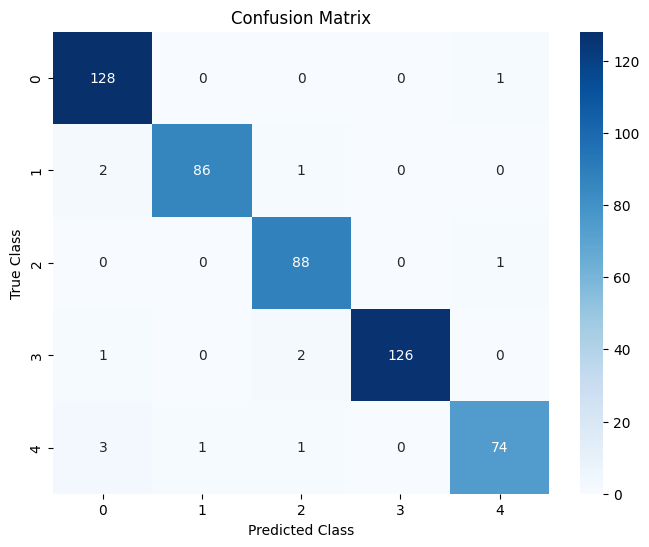

In [72]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('Confusion Matrix')
plt.show()

In [69]:
print(classification_report(y_logit_test, predicted_classes))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97       129
           1       0.99      0.97      0.98        89
           2       0.96      0.99      0.97        89
           3       1.00      0.98      0.99       129
           4       0.97      0.94      0.95        79

    accuracy                           0.97       515
   macro avg       0.97      0.97      0.97       515
weighted avg       0.98      0.97      0.97       515



# SVM

In [229]:
svm_model = LinearSVC(C = 1, max_iter = 1000)

In [230]:
svm_model.fit(X_train, y_train)

C:\Users\Taylor\miniconda3\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


LinearSVC(C=1)

In [231]:
svm_preds = svm_model.predict(X_test)

In [232]:
print(classification_report(y_test, svm_preds))

               precision    recall  f1-score   support

     business       0.97      0.98      0.97       117
entertainment       1.00      0.96      0.98        93
     politics       0.95      0.97      0.96       101
        sport       1.00      1.00      1.00       123
         tech       0.99      0.99      0.99        81

     accuracy                           0.98       515
    macro avg       0.98      0.98      0.98       515
 weighted avg       0.98      0.98      0.98       515



# Random Forest

In [240]:
rf = RandomForestClassifier(min_samples_split = 5, oob_score = True, random_state = 7)

In [241]:
rf.fit(X_train, y_train)

RandomForestClassifier(min_samples_split=5, oob_score=True, random_state=7)

In [242]:
rf_pred = rf.predict(X_test)

In [243]:
print(classification_report(y_test, rf_pred))

               precision    recall  f1-score   support

     business       0.94      1.00      0.97       117
entertainment       0.98      0.95      0.96        93
     politics       0.99      0.93      0.96       101
        sport       0.96      1.00      0.98       123
         tech       1.00      0.96      0.98        81

     accuracy                           0.97       515
    macro avg       0.97      0.97      0.97       515
 weighted avg       0.97      0.97      0.97       515



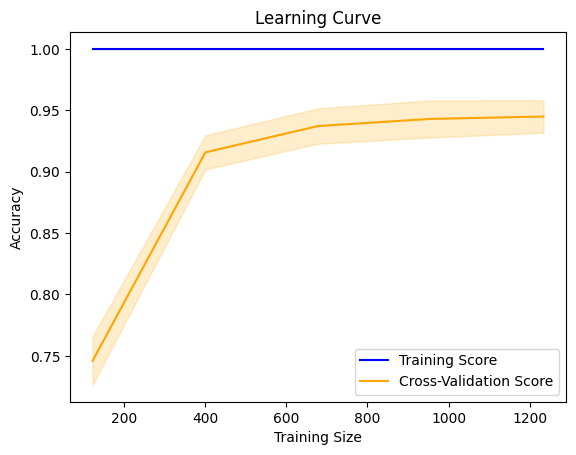

In [252]:
train_sizes, train_scores, test_scores = learning_curve(
    rf, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1
)

# Calculate mean and standard deviation
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot learning curve
plt.plot(train_sizes, train_mean, label="Training Score", color="blue")
plt.plot(train_sizes, test_mean, label="Cross-Validation Score", color="orange")

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color="blue", alpha=0.2)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, color="orange", alpha=0.2)

plt.title("Learning Curve")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.show()

# Extras

In [259]:
len(sums)

31223

In [258]:
(sums <= 5).sum()

23474

In [39]:
more_drop = sums.index[23474:31184]

In [40]:
more_drop = more_drop.tolist()

In [41]:
trimmed_df = full_df.drop(columns = more_drop, axis = 1)

In [300]:
X_trim = trimmed_df.iloc[:, 1:]
y_trim = trimmed_df.iloc[:, 0]

In [301]:
X_trim_train, X_trim_test, y_trim_train, y_trim_test = train_test_split(X, y, test_size = .25, random_state = 10)
svm_model_trim = LinearSVC(C = 1, max_iter = 1000)
svm_model_trim.fit(X_trim_train, y_trim_train)
trim_preds = svm_model_trim.predict(X_trim_test)
print(classification_report(y_trim_test, trim_preds))

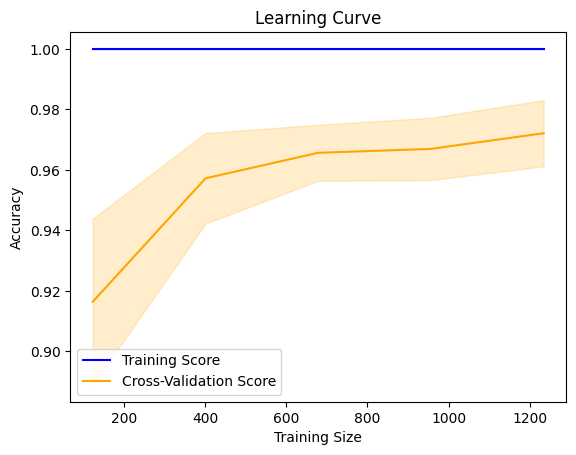

In [322]:
train_sizes, train_scores, test_scores = learning_curve(
    svm_model_trim, X_trim_train, y_trim_train, cv=5, scoring='accuracy', n_jobs=-1
)

# Calculate mean and standard deviation
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot learning curve
plt.plot(train_sizes, train_mean, label="Training Score", color="blue")
plt.plot(train_sizes, test_mean, label="Cross-Validation Score", color="orange")

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color="blue", alpha=0.2)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, color="orange", alpha=0.2)

plt.title("Learning Curve")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.show()

In [326]:
y_rf_trim = np.array(y_trim_train).ravel()

In [327]:
rf_trim = RandomForestClassifier(min_samples_split = 5, oob_score = True, random_state = 11)
rf_trim.fit(X_trim_train, y_rf_trim)
rf_trim_pred = rf_trim.predict(X_trim_test)
print(classification_report(y_trim_test, rf_trim_pred))

               precision    recall  f1-score   support

     business       0.95      0.97      0.96       128
entertainment       0.97      0.95      0.96        92
     politics       0.97      0.96      0.96        97
        sport       0.95      1.00      0.97       105
         tech       0.97      0.91      0.94        93

     accuracy                           0.96       515
    macro avg       0.96      0.96      0.96       515
 weighted avg       0.96      0.96      0.96       515



In [328]:
rf_trim.oob_score_

0.949449125081011

In [334]:
trimmed_df.shape

(2058, 23475)

In [42]:
more_to_drop = sums.index[7711:23474].tolist()

In [43]:
trimmed_again = trimmed_df.drop(columns = more_to_drop, axis = 1)

In [44]:
X_trim = trimmed_again.iloc[:, 1:]
y_trim = trimmed_again.iloc[:, 0]

In [45]:
X_trim_train02, X_trim_test02, y_trim_train02, y_trim_test02 = train_test_split(X_trim, y_trim, test_size = .25, random_state = 12)
#svm_model_trim02 = LinearSVC(C = 1, max_iter = 1000)
#svm_model_trim02.fit(X_trim_train02, y_trim_train02)
#trim_preds02 = svm_model_trim02.predict(X_trim_test02)
#print(classification_report(y_trim_test02, trim_preds02))

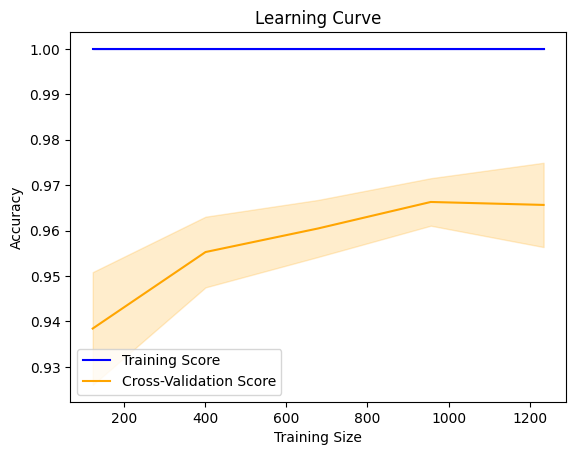

In [344]:
train_sizes, train_scores, test_scores = learning_curve(
    svm_model_trim02, X_trim_train02, y_trim_train02, cv=5, scoring='accuracy', n_jobs=-1
)

# Calculate mean and standard deviation
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot learning curve
plt.plot(train_sizes, train_mean, label="Training Score", color="blue")
plt.plot(train_sizes, test_mean, label="Cross-Validation Score", color="orange")

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color="blue", alpha=0.2)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, color="orange", alpha=0.2)

plt.title("Learning Curve")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.show()

In [346]:
y_rf_trim02 = np.array(y_trim_train02).ravel()

In [347]:
rf_trim02 = RandomForestClassifier(min_samples_split = 5, oob_score = True, random_state = 13)
rf_trim02.fit(X_trim_train02, y_rf_trim02)
rf_trim_pred02 = rf_trim02.predict(X_trim_test02)
print(classification_report(y_trim_test02, rf_trim_pred02))

               precision    recall  f1-score   support

     business       0.91      0.96      0.93       129
entertainment       0.95      0.94      0.95        89
     politics       0.95      0.93      0.94        89
        sport       0.98      0.98      0.98       129
         tech       0.97      0.91      0.94        79

     accuracy                           0.95       515
    macro avg       0.95      0.95      0.95       515
 weighted avg       0.95      0.95      0.95       515



In [350]:
rf_trim02.oob_score_

0.948152948801037

# LogisticRegression with CV

In [82]:
y_trim_array = y_trim_train02.ravel()
y_trim_array_test = y_trim_train02.ravel()

In [85]:
model04 = LogisticRegression(multi_class = 'multinomial', random_state = 40)
model04.fit(X_trim_train02, y_trim_train02)

LogisticRegression(multi_class='multinomial', random_state=40)

In [86]:
scores = cross_val_score(model04, X_trim_test02, y_trim_test02, cv=5, scoring='f1_macro')
print(scores)

[0.97066399 0.93425483 0.91973144 0.91731885 0.94663778]


In [87]:
scores.mean()

0.9377213787762241

In [88]:
scores.std()

0.01957874155826098

In [89]:
scores_ac = cross_val_score(model04, X_trim_test02, y_trim_test02, cv=5, scoring='accuracy')
print(scores_ac)

[0.97087379 0.94174757 0.9223301  0.9223301  0.95145631]


In [102]:
encoder = LabelEncoder()
y_encode_train = encoder.fit_transform(y_trim_train02)
y_encode_test = encoder.transform(y_trim_test02)

In [104]:
f1_macro_scorer = make_scorer(f1_score, average='macro')

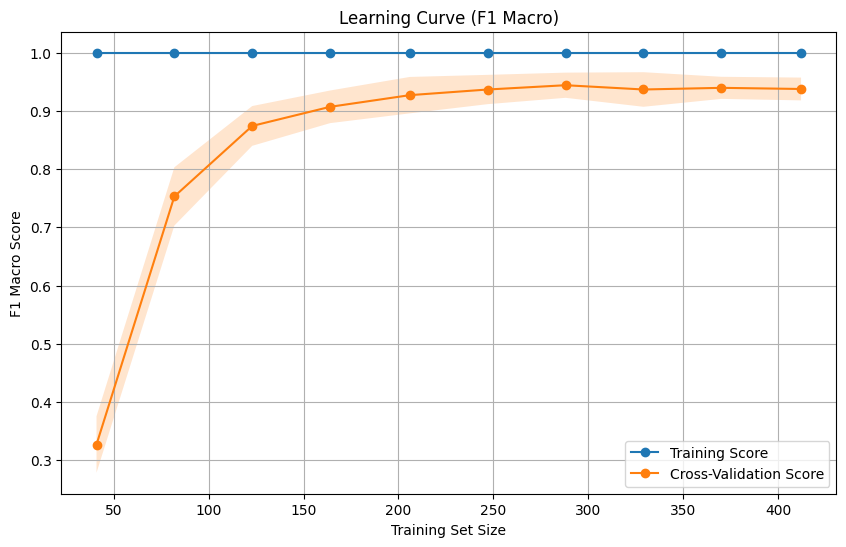

In [105]:
train_sizes, train_scores, test_scores = learning_curve(
    estimator = model04,
    X = X_trim_test02,
    y = y_encode_test,
    cv=5,  # Number of cross-validation folds
    scoring = f1_macro_scorer,
    train_sizes=np.linspace(0.1, 1.0, 10),  # Vary training set size
)

# Calculate mean and standard deviation for train and test scores
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, label="Training Score", marker='o')
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.2)
plt.plot(train_sizes, test_scores_mean, label="Cross-Validation Score", marker='o')
plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.2)

# Add labels and title
plt.title("Learning Curve (F1 Macro)")
plt.xlabel("Training Set Size")
plt.ylabel("F1 Macro Score")
plt.legend(loc="best")
plt.grid()
plt.show()